In [1]:
# Imports
import numpy as np
import scipy as sp
# for integration and interpolation
from scipy.integrate import quad
from scipy.interpolate import interp1d
# for parrallelism
from multiprocessing import Pool
# for plotting
import matplotlib.pyplot as plt

In [2]:
from constants_module import c, hbar_GeV, me, k, h
import b_loss as b

In [3]:
''' conversions '''
#d_cyg_ref = 1.5e+3           # reference distance of the Cygnus-X region, in [pc]
conv_pc_cm = 3.086e+18       # conversion factor from [pc] to [cm]
conv_cm_pc = 3.24e-19        # conversion factor from [cm] to [pc]
conv_s_yr = 3.171e-8         # conversion factor from [sec] to [yr]
conv_yr_sec = 3.154e+7       # conversion factor from [yr] to [sec]
conv_rad_degree = 57.2958    # conversion factor from [rad] to [deg]
c = 2.998e+10                # speed of light, in [cm/s]

In [4]:
class Params:
    """
    Holds all tunable parameters for the halo model.
    """
    def __init__(self):
        # injection spectrum
        self.alpha = 2.0          # power-law index
        self.Ecut = 1e6           # cutoff energy (GeV)

        # diffusion parameters
        self.rh = 30              # transition radius [pc]
        self.D0 = 1e26            # cm^2/s (inner zone)
        self.Dism = 4e28          # cm^2/s (outer zone)
        self.del_exponent = 1/3   # spectral index of diffusion coefficient

        # luminosity parameters
        self.tau0 = 12 * conv_yr_sec
        self.Edot = 3.8e34        # erg/s (for Monogem)
        self.tobs = 110e3 * conv_yr_sec  # observation time

        # location and distance perameters
        self.rs = 1             #galactic location of source

        # integration resolution
        self.n_points = 8

params = Params()

# Finding the B antiderivative

## Approximate Solution

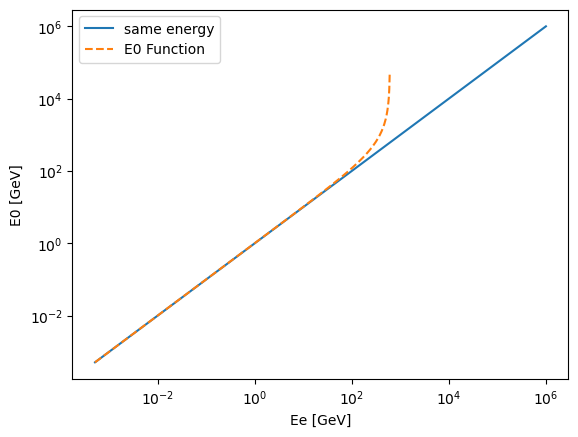

In [18]:
def E0_approx_analytic(Ee, tau):
    b0 = 1.4e-16
    # B(Ee) + tau = 1/b0 * (1/me - 1/Ee) + tau
    # Invert: 1/E0 = 1/me - b0*(B(Ee) + tau)
    B_val = (1/me - 1/Ee) / b0 + tau
    inv_E0 = 1/me - b0 * B_val
    if inv_E0 <= 0:
        return np.inf  # electron couldn't have survived to Ee in time tau
    return 1.0 / inv_E0

# Plotting
points = 1000
Ees = np.logspace(np.log10(me), np.log10(1e6), points)
tau = (370e3)*conv_yr_sec

vals = []
for i in range(points):
    E0_value = E0_approx_analytic(Ees[i], tau)
    vals.append(E0_value)


plt.loglog(Ees, Ees, label = "same energy")
plt.loglog(Ees, vals, label = "E0 Function", linestyle = "dashed")
plt.legend()
plt.xlabel("Ee [GeV]")
plt.ylabel("E0 [GeV]")
plt.show()

In [19]:
def diffusion_len_approx(Ee, tau, r=0):
    '''
    Analytic approximation to the diffusion length using:
        b(E)  = b0 * E^2  (quadratic energy loss)
        D(E)  = D0 * E^(1/3)  (inner zone, r < rh)
    
    Result is in cm. Multiply by conv_cm_pc to get parsecs.

    - params -
    Ee:  observed electron energy (GeV)
    tau: tobs - tinj (s)
    r:   distance from pulsar (pc) — only affects which D0 is used
    '''
    b0 = 1.4e-16   # GeV^-1 s^-1
    rh = 30        # pc

    if r < rh:
        D0 = 1e26  # cm^2/s
    else:
        D0 = 4e28  # cm^2/s

    # Analytic E0
    B_ee = (1/me - 1/Ee) / b0
    inv_E0 = 1/me - b0 * (B_ee + tau)
    
    if inv_E0 <= 0:
        return 0.0  # electron couldn't have reached Ee in time tau

    E0 = 1.0 / inv_E0

    # Analytic diffusion length integral
    integral = (3 * D0) / (2 * b0) * (Ee**(-2/3) - E0**(-2/3))

    if integral <= 0:
        return 0.0

    return np.sqrt(4 * integral)

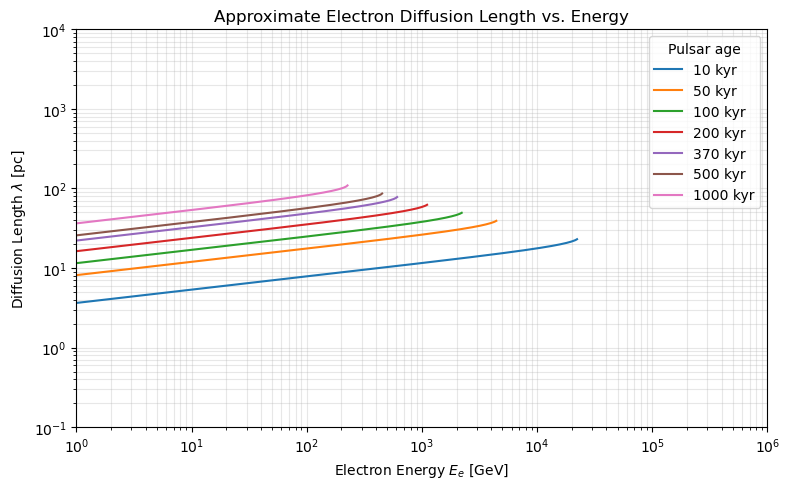

In [24]:
ages_kyr = [10, 50, 100, 200, 370, 500, 1000]
Ee_vals  = np.logspace(0, 6, 600)

fig, ax = plt.subplots(figsize=(8, 5))

for age_kyr in ages_kyr:
    tau    = age_kyr * 1e3 * conv_yr_sec
    lam_pc = np.array([diffusion_len_approx(Ee, tau) * conv_cm_pc for Ee in Ee_vals])
    mask   = lam_pc > 0
    ax.loglog(Ee_vals[mask], lam_pc[mask], label=f"{age_kyr} kyr")

ax.set_xlabel("Electron Energy $E_e$ [GeV]")
ax.set_ylabel("Diffusion Length $\\lambda$ [pc]")
ax.set_title("Approximate Electron Diffusion Length vs. Energy")
ax.set_xlim(1, 1e6)
ax.set_ylim(0.1, 1e4)
ax.legend(title="Pulsar age")
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

## Streamlined Full Solution

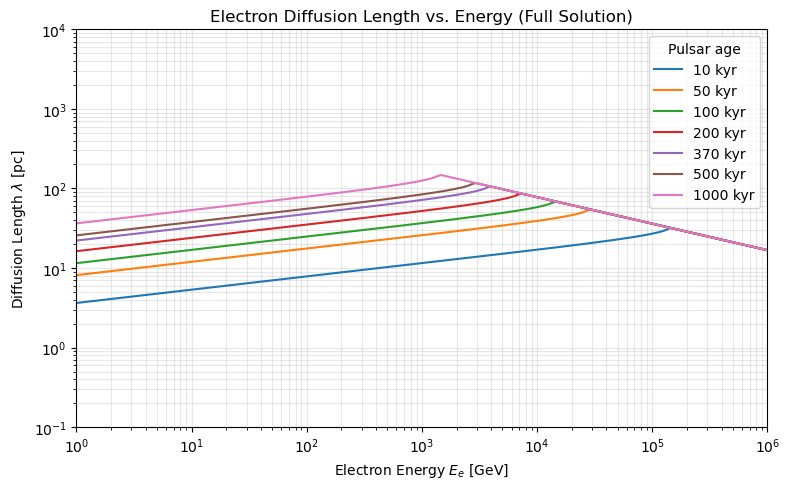

In [36]:
# ── B(E) antiderivative and spline ─────────────────────────────────────────────
def B_anti(Ex, Emin=me):
    """Integral of 1/b_tot from Emin to Ex."""
    pts = np.logspace(np.log10(Emin), np.log10(Ex), 200)
    # Lambda function optimization --> cool
    result, _ = quad((lambda E: 1.0 / b.b_tot(E)), Emin, Ex,
                     points=pts, epsabs=1e-12, epsrel=1e-10, limit=500)
    return result

def build_E0_spline(Emin=me, Emax=1e7, n_points=1000):
    """
    Build inverse spline: B_value → E.
    Emax capped at 1e7 GeV — B(E) saturates beyond this,
    making inversion numerically unstable.
    """
    Es = np.logspace(np.log10(Emin), np.log10(Emax), n_points)
    Bs = np.array([B_anti(E) for E in Es])
    return interp1d(Bs, Es, kind='cubic', bounds_error=False, fill_value='extrapolate')

E0_spline = build_E0_spline()

def E0_val(Ee, tau):
    """Initial energy of an electron observed at Ee after time tau."""
    return float(E0_spline(B_anti(Ee) + tau))

# ── Diffusion coefficient ──────────────────────────────────────────────────────
def D(Ee, r):
    """Two-zone diffusion coefficient(from Hooper)."""
    rh  = 30    # pc
    D0  = 1e26  # cm^2/s  (inner)
    Dism = 4e28 # cm^2/s  (outer)
    delta = 1/3 
    coeff = D0 if r < rh else Dism
    return coeff * (Ee / 1.0)**delta

# ── Diffusion length ───────────────────────────────────────────────────────────
def diffusion_len(Ee, tau, r=0):
    E0 = E0_val(Ee, tau)

    # Checks if E0 value is nonphysical, sets to 0 if so
    if E0 <= Ee:
        return 0.0

    pts = np.logspace(np.log10(Ee), np.log10(E0), 300)
    result, _ = quad((lambda E: D(E, r) / b.b_tot(E)) , Ee, E0,
                     points=pts, epsabs=1e-12, epsrel=1e-10, limit=500)

    return np.sqrt(4 * result) if result > 0 else 0.0

# ── Plot ───────────────────────────────────────────────────────────────────────
ages_kyr = [10, 50, 100, 200, 370, 500, 1000]
Ee_vals  = np.logspace(0, 6, 200)

fig, ax = plt.subplots(figsize=(8, 5))

for age_kyr in ages_kyr:
    tau    = age_kyr * 1e3 * conv_yr_sec
    lam_pc = np.array([diffusion_len(Ee, tau) * conv_cm_pc for Ee in Ee_vals])
    mask   = lam_pc > 0
    ax.loglog(Ee_vals[mask], lam_pc[mask], label=f"{age_kyr} kyr")

ax.set_xlabel("Electron Energy $E_e$ [GeV]")
ax.set_ylabel("Diffusion Length $\\lambda$ [pc]")
ax.set_title("Electron Diffusion Length vs. Energy (Full Solution)")
ax.set_xlim(1, 1e6)
ax.set_ylim(0.1, 1e4)
ax.legend(title="Pulsar age")
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

## Claude Continued

B ceiling: 1.8983e+19 s/GeV


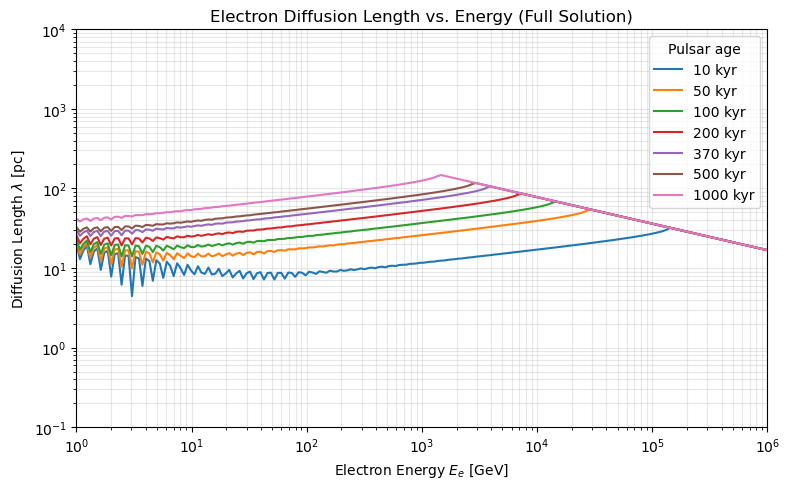

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.interpolate import interp1d

# ── Constants ──────────────────────────────────────────────────────────────────
me = 5.11e-4           # electron rest mass in GeV
conv_yr_sec = 3.154e7  # yr → s
conv_cm_pc  = 3.24e-19 # cm → pc

# ── Energy loss ────────────────────────────────────────────────────────────────
def Si(Ee, Ti):
    """KN suppression factor (arXiv:2010.13825)."""
    k_GeV = 8.617e-14
    Ai = (45 * me**2) / (64 * np.pi**2 * k_GeV * Ti**2)
    return Ai / (Ai + (Ee / me)**2)

def b_tot(Ee):
    """Total energy loss rate: ICS (CMB + IR + starlight) + synchrotron."""
    sig_T = (8/3) * np.pi * (2.82e-13)**2
    c     = 2.998e10

    components = [
        (0.26e-9, 2.75),
        (0.60e-9, 20),
        (0.60e-9, 5000),
    ]
    b_ics = sum(
        (4 * sig_T * u * Si(Ee, T) * c / 3) * (Ee / me)**2
        for u, T in components
    )
    u_B   = 0.22e-9
    b_syn = (4/3) * sig_T * c * u_B * (Ee / me)**2

    return b_ics + b_syn

# ── B(E) saturation ceiling ────────────────────────────────────────────────────
# B(E) = integral of 1/b from me to E saturates as E→∞.
# Compute it numerically once at a very high energy to get the ceiling.
def _compute_B_ceiling(E_high=1e9):
    pts = np.logspace(np.log10(me), np.log10(E_high), 500)
    result, _ = quad(lambda E: 1.0 / b_tot(E), me, E_high,
                     points=pts, epsabs=1e-14, epsrel=1e-12, limit=1000)
    return result

B_CEILING = _compute_B_ceiling()
print(f"B ceiling: {B_CEILING:.4e} s/GeV")

# ── B(E) antiderivative and spline ─────────────────────────────────────────────
def B_anti(Ex, Emin=me):
    pts = np.logspace(np.log10(Emin), np.log10(Ex), 200)
    result, _ = quad(lambda E: 1.0 / b_tot(E), Emin, Ex,
                     points=pts, epsabs=1e-12, epsrel=1e-10, limit=500)
    return result

def build_E0_spline(Emin=me, Emax=1e7, n_points=800):
    Es = np.logspace(np.log10(Emin), np.log10(Emax), n_points)
    Bs = np.array([B_anti(E) for E in Es])
    return interp1d(Bs, Es, kind='linear', bounds_error=False, fill_value='extrapolate')

E0_spline = build_E0_spline()

def E0_val(Ee, tau):
    """
    Return E0 given Ee and tau.
    If B(Ee) + tau exceeds the saturation ceiling, E0 is effectively
    infinite — the electron hasn't cooled appreciably — so return np.inf.
    """
    B_val = B_anti(Ee) + tau
    if B_val >= B_CEILING:
        return np.inf
    return float(E0_spline(B_val))

# ── Diffusion coefficient ──────────────────────────────────────────────────────
def D(Ee, r):
    rh   = 30
    D0   = 1e26
    Dism = 4e28
    coeff = D0 if r < rh else Dism
    return coeff * (Ee / 1.0)**(1/3)

# ── Diffusion length ───────────────────────────────────────────────────────────
# D(E)/b(E) ~ E^(1/3) / E^2 = E^(-5/3), which converges at infinity.
# So when E0 = inf we can safely integrate to a finite surrogate upper limit.
E_INF_SURROGATE = 1e30  # GeV — well into convergence tail

def diffusion_len(Ee, tau, r=0):
    """
    Diffusion length in cm.
    Handles E0=inf correctly by integrating to E_INF_SURROGATE.
    """
    E0 = E0_val(Ee, tau)

    if E0 != np.inf and E0 <= Ee:
        return 0.0

    E_upper = E_INF_SURROGATE if E0 == np.inf else E0

    pts = np.logspace(np.log10(Ee), np.log10(E_upper), 300)
    result, _ = quad(lambda E: D(E, r) / b_tot(E), Ee, E_upper,
                     points=pts, epsabs=1e-12, epsrel=1e-10, limit=500)

    return np.sqrt(4 * result) if result > 0 else 0.0

# ── Plot ───────────────────────────────────────────────────────────────────────
ages_kyr = [10, 50, 100, 200, 370, 500, 1000]
Ee_vals  = np.logspace(0, 6, 200)

fig, ax = plt.subplots(figsize=(8, 5))

for age_kyr in ages_kyr:
    tau    = age_kyr * 1e3 * conv_yr_sec
    lam_pc = np.array([diffusion_len(Ee, tau) * conv_cm_pc for Ee in Ee_vals])
    mask   = lam_pc > 0
    ax.loglog(Ee_vals[mask], lam_pc[mask], label=f"{age_kyr} kyr")

ax.set_xlabel("Electron Energy $E_e$ [GeV]")
ax.set_ylabel("Diffusion Length $\\lambda$ [pc]")
ax.set_title("Electron Diffusion Length vs. Energy (Full Solution)")
ax.set_xlim(1, 1e6)
ax.set_ylim(0.1, 1e4)
ax.legend(title="Pulsar age")
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

## Full solution with proper energy losses

In [5]:
def B_anti(Ex, Emin=me):    
    '''
    Computes the antiderivative of 1/btot at a given energy to then later
    solve for E0 (the intial electron energy) as a function of Ee and t.
    Utilizes logspace to get the integral to work out properly.

    - perams - 
    Ex: some electron energy value to evaluate at
    Emin: minimum value for the integral, set to 0.1 GeV ( for now )

    - returns - 
    the antiderivative of 1/btot evaluated at Ex
    '''
    E_test = np.logspace(np.log10(me), np.log10(Ex), 200)

    def integrand_B(Ex):
        return 1 / b.b_tot(Ex)
    
    # Old one with points = E_test
    result, error = quad(integrand_B, Emin, Ex, points = E_test, 
                        epsabs=1e-12, epsrel=1e-10, limit = 500)
    
    #result, error = quad(integrand_B, Emin, Ex,
    #                     epsabs=1e-12, epsrel=1e-10, limit = 1000)
    
    return result

def spline_to_E0s(Emin = me, Emax = 1e100):
    n_points = 1000

    Es = np.logspace(np.log10(Emin), np.log10(Emax), n_points)

    Bs_at_Es = []
    for i in range(n_points):
        Bs_at_Es.append(B_anti(Es[i]))

    inv_spline = interp1d(Bs_at_Es, Es, kind='linear', bounds_error=False, fill_value='extrapolate')

    return inv_spline

''' global variable '''
# spline for interpolating E0
E0_spline = spline_to_E0s()

def E0_val(Ee, tau):
    '''
    Computes the inital photon energy as a function of final
    photon energy and time difference between observation and 
    injection(tstar). Utilizes a inverse function spline to find
    the E0 that solves the necessary equation for a given Ee and
    tau.

    - perams -
    Ee: final photon energy
    tau: tobs - tinj (Defined in the hooper paper)

    - returns - 
    value of E0 at given Ee and tau
    maximum value of Ee for wich the function is defined, above that 
    there isn't any well defined values
    '''
    value = B_anti(Ee) + tau
    E0 = E0_spline(value)
    return E0

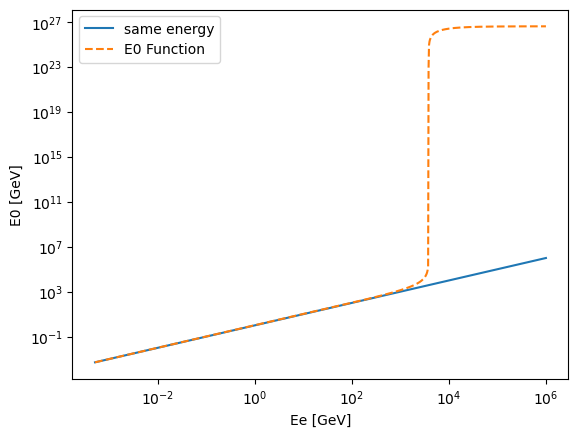

In [ ]:
points = 1000
Ees = np.logspace(np.log10(me), np.log10(1e6), points)
tau = (370e3)*conv_yr_sec

vals = []
vals_2 = []
for i in range(points):
    vals.append(B_anti(Ees[i]) + tau)
    E0_value = E0_val(Ees[i], tau)
    vals_2.append(E0_value)


# plt.loglog(Ees, E0_spline(vals), label = "Direct E0")
plt.loglog(Ees, Ees, label = "same energy")
plt.loglog(Ees, vals_2, label = "E0 Function", linestyle = "dashed")
plt.legend()
plt.xlabel("Ee [GeV]")
plt.ylabel("E0 [GeV]")
plt.show()

In [7]:
for i in range(points):
    if (E0_value < Ees[i]):
        print(f"E0 < Ee: {E0_value} < {Ees[i]}")

In [10]:
def spline_to_E0s(tau, Emin=me, Emax=1e40):
    n_points = 500
    Es = np.logspace(np.log10(Emin), np.log10(Emax), n_points)
    Bs = np.array([B_anti(E + tau) for E in Es])

    if not np.all(np.diff(Bs) > 0):
        print("⚠️ Warning: B(E) not strictly increasing!")
        idx = np.where(np.diff(Bs) <= 0)[0]
        print(f"Non-monotonic regions near E = {Es[idx]} GeV")

    return interp1d(Bs, Es, kind='linear', fill_value='extrapolate', bounds_error=False)

E0_spline = spline_to_E0s(params.tau0)

⚠️ Warning: B(E) not strictly increasing!
Non-monotonic regions near E = [5.11000000e-04 6.23989917e-04 9.30445446e-04 1.13618117e-03
 1.38740820e-03 1.69418538e-03 2.06879568e-03 2.52623805e-03
 3.08482793e-03 3.76693057e-03 4.59985654e-03 5.61695518e-03
 6.85894989e-03 8.37556863e-03 1.02275350e-02 1.52505082e-02
 3.39086893e-02 4.14064191e-02 6.17420460e-02 7.53941568e-02
 1.12421929e-01 1.67634875e-01 2.04701510e-01 2.49964145e-01
 3.72727178e-01 5.55781906e-01 6.78673787e-01 1.01198580e+00
 1.50899486e+00 1.84265671e+00 2.74762701e+00 5.00296876e+00
 6.10920168e+00 7.46003962e+00 9.10956850e+00 1.11238334e+01
 2.02546383e+01 3.02021482e+01 4.50351048e+01 5.49930554e+01
 8.20013860e+01 1.22274117e+02 1.82325695e+02 3.31984566e+02
 4.95029678e+02 6.04488312e+02 1.10067201e+03 1.64123687e+03
 2.44728534e+03 2.98841757e+03 4.45609687e+03 5.44140805e+03
 6.64458661e+03 9.90789304e+03 1.47738829e+04 1.80406144e+04
 3.28489384e+04 4.01123412e+04 5.98124172e+04 7.30378575e+04
 1.08908398e

/opt/anaconda3/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:701: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


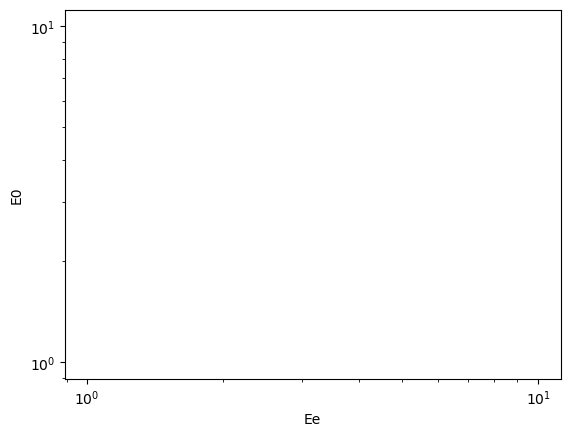

In [11]:
Emin=me
Emax=1e7
n_points = 500
Es = np.logspace(np.log10(Emin), np.log10(Emax), n_points)

plt.loglog(Es, E0_spline(Es))
plt.xlabel("Ee")
plt.ylabel("E0")
plt.show()

In [12]:
def E0_val(Ee, tau):
    '''
    Computes the inital photon energy as a function of final
    photon energy and time difference between observation and 
    injection(tstar). Utilizes a inverse function spline to find
    the E0 that solves the necessary equation for a given Ee and
    tau.

    - params -
    Ee: final photon energy
    tau: tobs - tinj (Defined in the hooper paper)

    - returns - 
    value of E0 at given Ee and tau
    maximum value of Ee for wich the function is defined, above that 
    there isn't any well defined values
    '''
    value = B_anti(Ee) + tau
    return float(E0_spline(value))

In [13]:
# Test times
t = params.t_age/2
tobs = params.tobs
tdiff = tobs - t

# Testing if any of the values are bad
Ee_test = np.logspace(-2, 5, 200)
E0_test = np.array([E0_val(Ee, tdiff) for Ee in Ee_test])
print(np.any(E0_test < Ee_test))

# printing where those values are bad
bad = np.where(E0_test < Ee_test)[0]
print("Problematic energies:", Ee_test[bad])

True
Problematic energies: [1.00000000e-02 1.08436597e-02 1.17584955e-02 1.27505124e-02
 1.38262217e-02 1.49926843e-02 1.62575567e-02 1.76291412e-02
 1.91164408e-02 2.07292178e-02 2.24780583e-02 2.43744415e-02
 2.64308149e-02 2.86606762e-02 3.10786619e-02 3.37006433e-02
 3.65438307e-02 3.96268864e-02 4.29700470e-02 4.65952567e-02
 5.05263107e-02 5.47890118e-02 5.94113398e-02 6.44236351e-02
 6.98587975e-02 7.57525026e-02 8.21434358e-02 8.90735464e-02
 9.65883224e-02 1.04737090e-01 1.13573336e-01 1.23155060e-01
 1.33545156e-01 1.44811823e-01 1.57029012e-01 1.70276917e-01
 1.84642494e-01 2.00220037e-01 2.17111795e-01 2.35428641e-01
 2.55290807e-01 2.76828663e-01 3.00183581e-01 3.25508860e-01
 3.52970730e-01 3.82749448e-01 4.15040476e-01 4.50055768e-01
 4.88025158e-01 5.29197874e-01 5.73844165e-01 6.22257084e-01
 6.74754405e-01 7.31680714e-01 7.93409667e-01 8.60346442e-01
 9.32930403e-01 1.01163798e+00 1.09698580e+00 1.18953407e+00
 1.28989026e+00 1.39871310e+00 1.51671689e+00 1.64467618e+

In [14]:
def diffusion_hoop(Ee, r):
    ''' 
    Diffusion model from the hooper paper, uses a two zone diffusion model
    with a factor rh that describes where the model changes from one zone
    to the next. Spherical diffusion is required by the results of the 
    Luque et. al. paper. 

    - perams -
    r: distance from center of pulsar halo
    '''
    # rh: radius when the diffusion model 'switches zones, set as 30 pc in hooper
    rh = 30 # parsecs
    if r < rh: 
        # coefficient for r < rh
        D0 = 1e26 # cm^2 / s
        del_exponent = 1/3 # hooper default

        # (Ee/1 GeV) below is just 1 because we are already in GeV
        return D0*(Ee/1)**del_exponent
    elif r >= rh:
        Dism = 4e28 # cm^2 / s
        del_ism = 1/3

        return Dism*(Ee/1)**del_ism
    else:
        print(f'Error in reading in radius for diffusion')
        return 0 

def diffusion_len(E0, Ee, r):
    '''
    Uses the diffusion coefficient to find the diffusion length.

    - perams - 
    Ee: final electron energy (GeV)
    E0: intial electron energy (GeV)

    - returns - 
    diffusion length
    '''
    def diffusion_integrand(Ee, r):
        return diffusion_hoop(Ee, r)/b.b_tot(Ee)
    
    E0_max = 1e9 #maximum energy electron that is produced by the halo

    '''
    Positron flux and γ-ray emission from Geminga pulsar and pulsar wind nebula
    --> mentions to use this for the bounds of integration
    '''

    result = quad(diffusion_integrand, Ee, min(E0, E0_max), r)[0]

    if result < 0:
        print(f"diffu_len < 0: E0 = {E0}, Ee = {Ee}, r = {r}")

    return np.sqrt(4*result)

Error for Ee=1.0: float division by zero
Error for Ee=1.1497569953977358: must be real number, not complex
Error for Ee=1.321941148466029: must be real number, not complex
Error for Ee=1.5199110829529336: must be real number, not complex
Error for Ee=1.7475284000076838: must be real number, not complex
Error for Ee=2.0092330025650473: must be real number, not complex
Error for Ee=2.3101297000831598: must be real number, not complex
Error for Ee=2.6560877829466865: must be real number, not complex
Error for Ee=3.0538555088334154: must be real number, not complex
Error for Ee=3.511191734215131: must be real number, not complex
Error for Ee=4.0370172585965545: must be real number, not complex
Error for Ee=4.641588833612779: must be real number, not complex
Error for Ee=5.3366992312063095: must be real number, not complex
Error for Ee=6.1359072734131725: must be real number, not complex
Error for Ee=7.054802310718643: must be real number, not complex
Error for Ee=8.111308307896872: must be

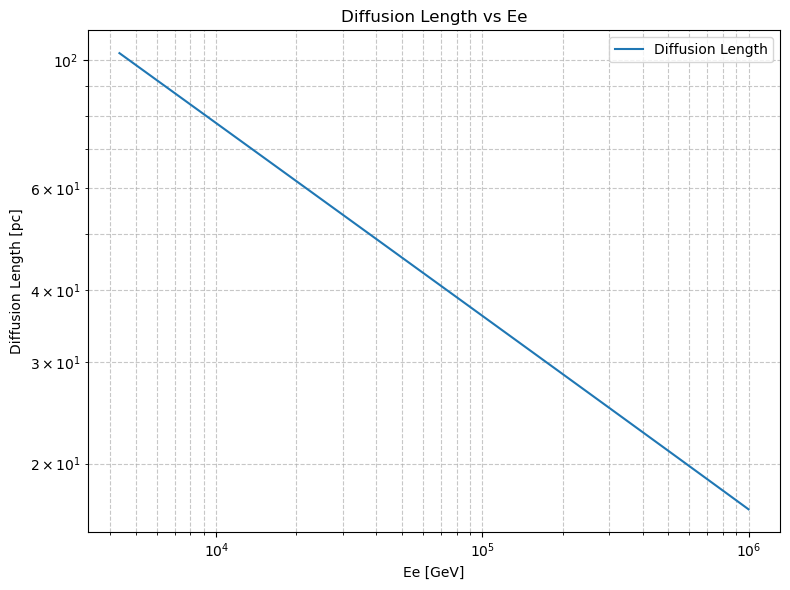

In [15]:
# Define parameters for the plot
E0 = 1e6  # Initial energy in GeV (example value)
r = 0     # Distance in parsecs (example value)

# Generate a range of Ee values
Ee_values = np.logspace(0, 6, 100)  # From 1 GeV to 1e6 GeV
diffusion_lengths = []

# time for monogem
tage = (370e3)*conv_yr_sec # tobs in seconds


# Compute diffusion lengths for each Ee
for Ee in Ee_values:
    try:
        E0 = E0_val(Ee, tage)
        diffusion_lengths.append(diffusion_len(E0, Ee, r)*conv_cm_pc)
    except Exception as e:
        print(f"Error for Ee={Ee}: {e}")
        diffusion_lengths.append(np.nan)

# Plot the diffusion length
plt.figure(figsize=(8, 6))
plt.loglog(Ee_values, diffusion_lengths, label="Diffusion Length")
plt.xlabel("Ee [GeV]")
plt.ylabel("Diffusion Length [pc]")
plt.title("Diffusion Length vs Ee")
plt.grid(True, which="both", linestyle="--", alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()